# Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Supervised Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Deep Learning
from keras.models import Model
from keras.layers import Input, Dense
from keras import regularizers

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Misc
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset

In [2]:
# Load the fraudTest.csv dataset
df = pd.read_csv('fraudTest.csv')

# Preview the dataset
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


# Exploratory Data Analysis (EDA)

# Class Distribution (Fraudulent vs Non-Fraudulent Transactions)

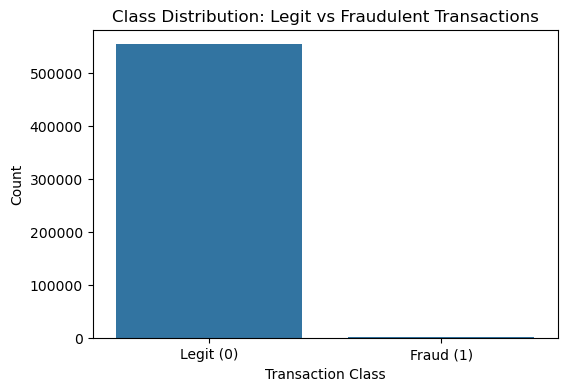

Percentage of fraudulent transactions: 0.39%


In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df)
plt.title("Class Distribution: Legit vs Fraudulent Transactions")
plt.xticks([0, 1], ['Legit (0)', 'Fraud (1)'])
plt.xlabel("Transaction Class")
plt.ylabel("Count")
plt.show()

fraud_pct = df['is_fraud'].value_counts(normalize=True)[1] * 100
print(f"Percentage of fraudulent transactions: {fraud_pct:.2f}%")

# Transaction Amount Distribution

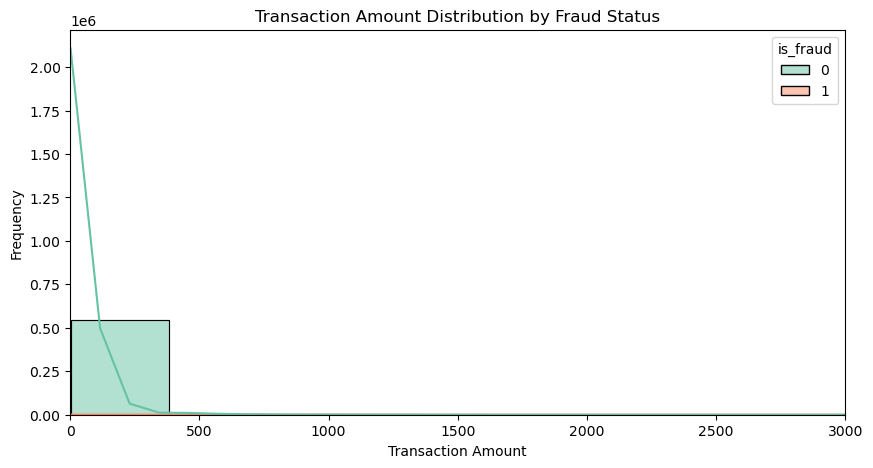

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='amt', hue='is_fraud', bins=60, kde=True, palette='Set2')
plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.xlim(0, 3000)  # focus on typical range
plt.show()

# Fraud Rate per Merchant Category

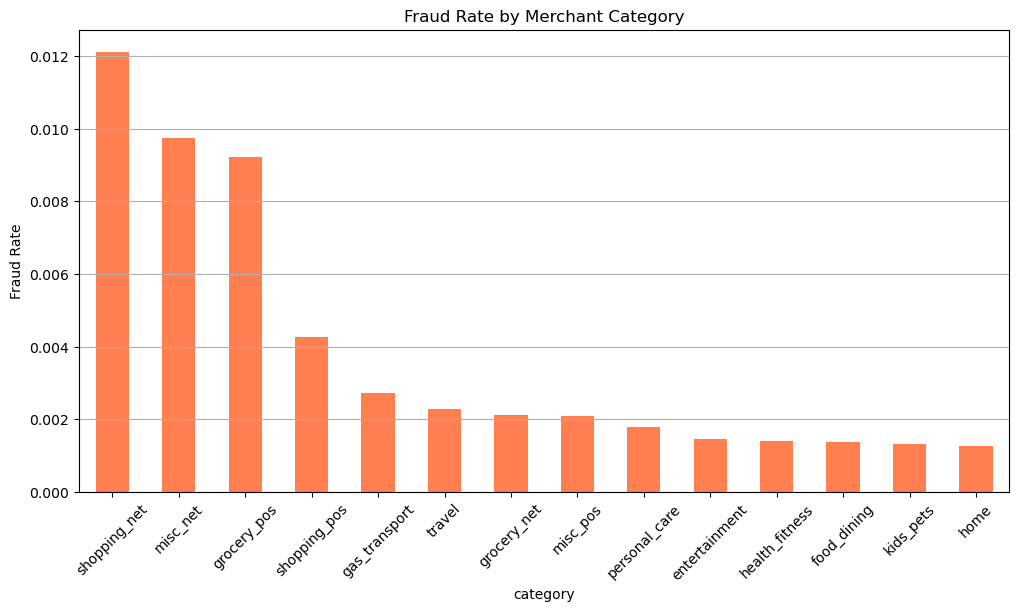

In [5]:
category_fraud_rate = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
category_fraud_rate.plot(kind='bar', color='coral')
plt.title("Fraud Rate by Merchant Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# City Population vs Fraud Cases

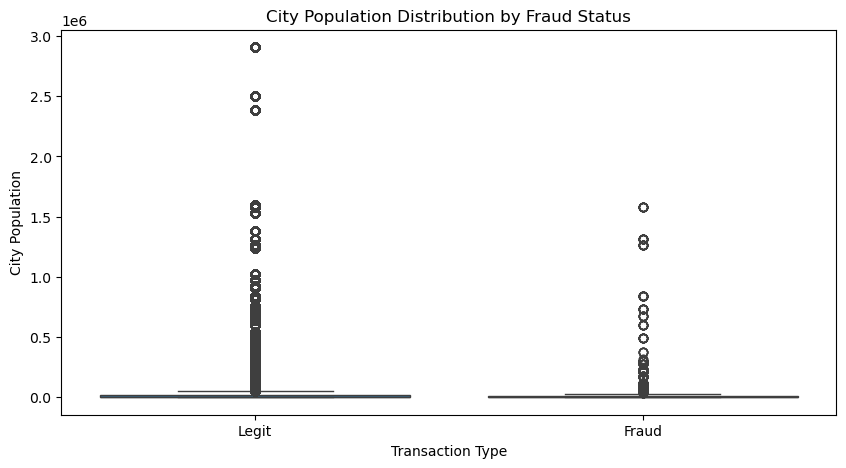

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_fraud', y='city_pop', data=df)
plt.title("City Population Distribution by Fraud Status")
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.xlabel("Transaction Type")
plt.ylabel("City Population")
plt.show()

# Heatmap of Correlation Matrix

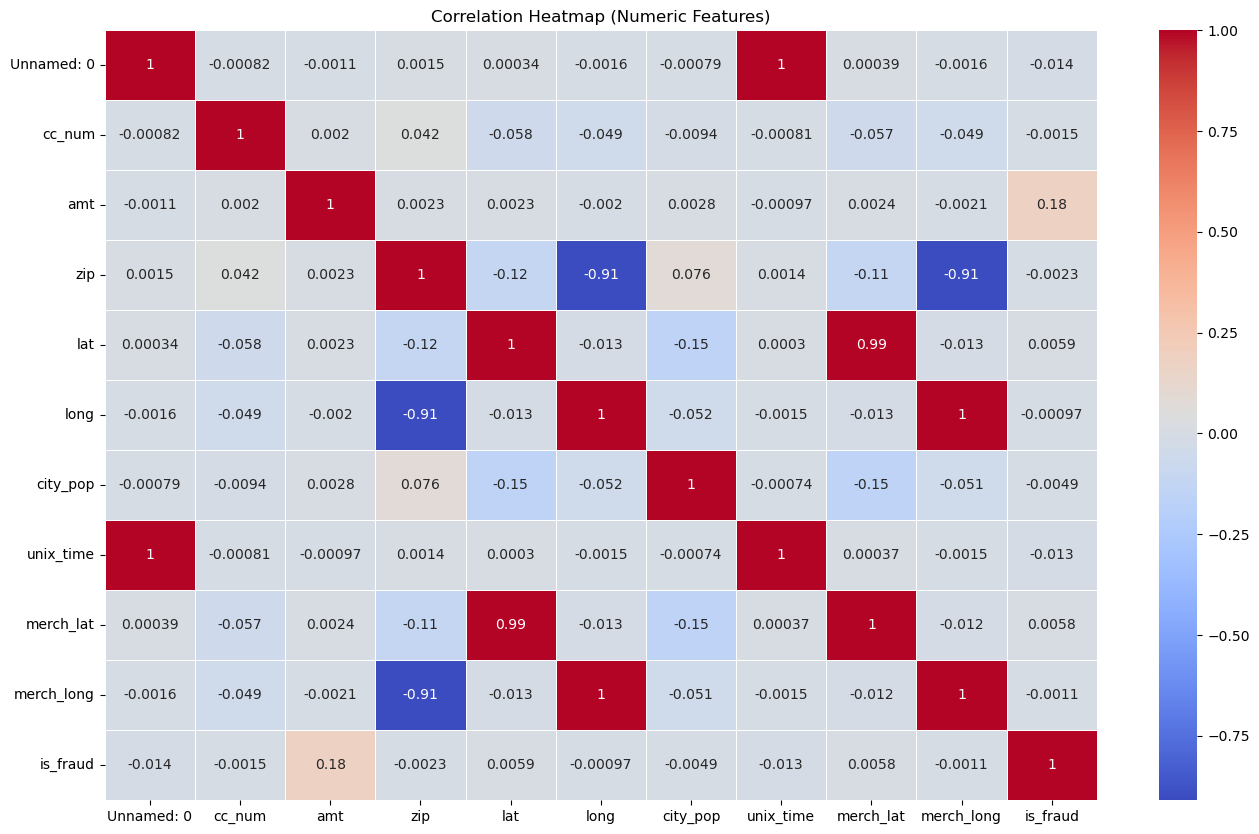

In [7]:
# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(16, 10))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# Top 10 Jobs with Highest Fraud Rate

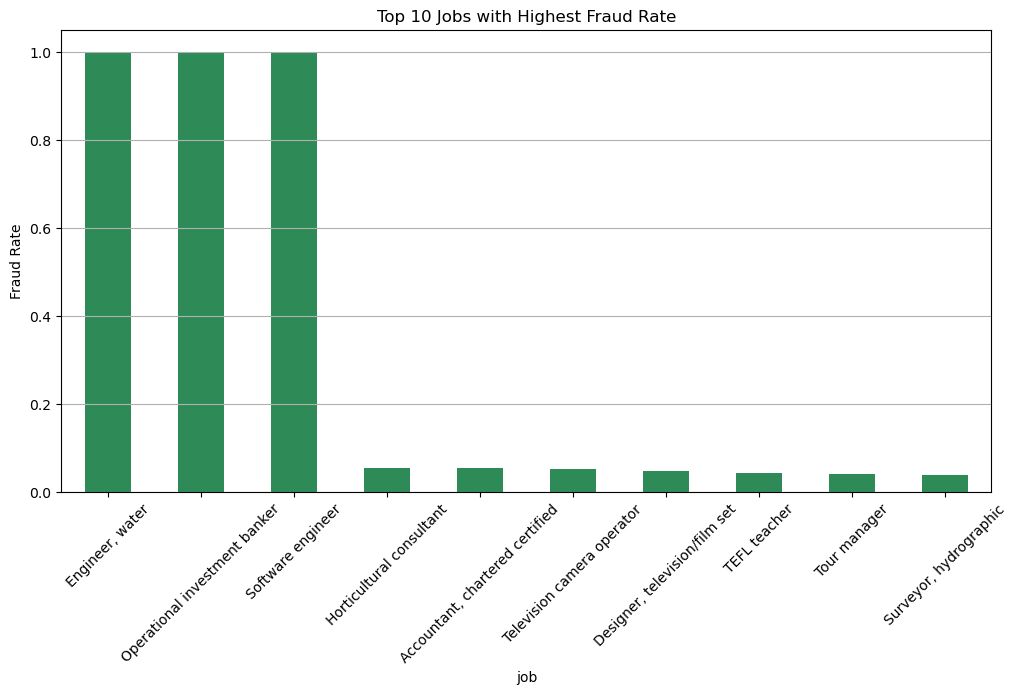

In [8]:
job_fraud_rate = df.groupby('job')['is_fraud'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
job_fraud_rate.plot(kind='bar', color='seagreen')
plt.title("Top 10 Jobs with Highest Fraud Rate")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# Data Preprocessing

In [9]:
# Drop only the columns that exist in the DataFrame
cols_to_drop = ['id', 'trans_date_trans_time', 'cc_num', 'first', 'last', 
                'street', 'city', 'state', 'zip', 'dob', 'trans_num', 
                'unix_time', 'merchant']

existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df.drop(columns=existing_cols_to_drop, inplace=True)

# Encode categorical variables using one-hot encoding
cat_cols = ['category', 'gender', 'job']
cat_cols = [col for col in cat_cols if col in df.columns]  # ensure the columns exist
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Supervised Learning Models

In [10]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred), 4))
    
    if y_prob is not None:
        print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))

# Decision Tree Classifier

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [12]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("🔍 Decision Tree Results:")
evaluate_model(dt_model, X_test, y_test)

🔍 Decision Tree Results:
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.66      0.66      0.66       429

    accuracy                           1.00    111144
   macro avg       0.83      0.83      0.83    111144
weighted avg       1.00      1.00      1.00    111144

Confusion Matrix:
 [[110569    146]
 [   146    283]]
Accuracy: 0.9974
Precision: 0.6597
Recall: 0.6597
F1 Score: 0.6597
AUC-ROC: 0.8292


# Random Forest Classifier

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("🌲 Random Forest Results:")
evaluate_model(rf_model, X_test, y_test)

🌲 Random Forest Results:
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.93      0.57      0.71       429

    accuracy                           1.00    111144
   macro avg       0.97      0.78      0.85    111144
weighted avg       1.00      1.00      1.00    111144

Confusion Matrix:
 [[110698     17]
 [   185    244]]
Accuracy: 0.9982
Precision: 0.9349
Recall: 0.5688
F1 Score: 0.7072
AUC-ROC: 0.9905


# Logistic Regression

In [14]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("📈 Logistic Regression Results:")
evaluate_model(lr_model, X_test, y_test)

📈 Logistic Regression Results:
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.33      0.05      0.09       429

    accuracy                           1.00    111144
   macro avg       0.66      0.53      0.55    111144
weighted avg       0.99      1.00      0.99    111144

Confusion Matrix:
 [[110669     46]
 [   406     23]]
Accuracy: 0.9959
Precision: 0.3333
Recall: 0.0536
F1 Score: 0.0924
AUC-ROC: 0.9291


# MLP Classifier (Neural Network)

In [15]:
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_model.fit(X_train, y_train)

print("🧠 MLP Neural Network Results:")
evaluate_model(mlp_model, X_test, y_test)

🧠 MLP Neural Network Results:
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.81      0.72      0.76       429

    accuracy                           1.00    111144
   macro avg       0.90      0.86      0.88    111144
weighted avg       1.00      1.00      1.00    111144

Confusion Matrix:
 [[110643     72]
 [   120    309]]
Accuracy: 0.9983
Precision: 0.811
Recall: 0.7203
F1 Score: 0.763
AUC-ROC: 0.9955


# K-Means Clustering

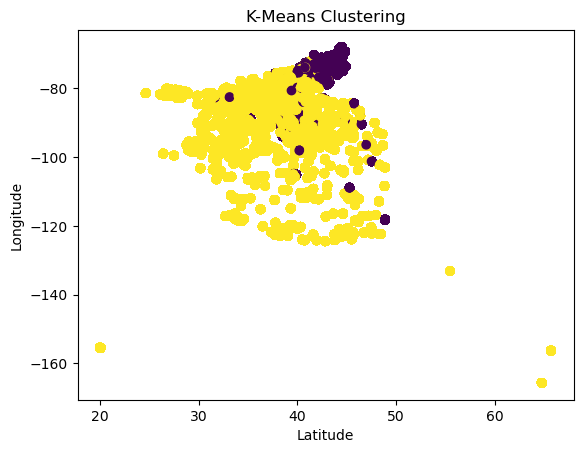

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Assuming 'df' is the DataFrame containing your dataset
# Drop the target column and scale features
X = df.drop(columns=['is_fraud'])  # Drop target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means with k clusters
kmeans = KMeans(n_clusters=2, random_state=42)  # For binary classification (e.g., fraud, not fraud)
kmeans.fit(X_scaled)

# Add the cluster labels to the dataframe
df['Cluster'] = kmeans.labels_

# Visualizing the clusters
plt.scatter(df['lat'], df['long'], c=df['Cluster'], cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

# Principal Component Analysis (PCA)

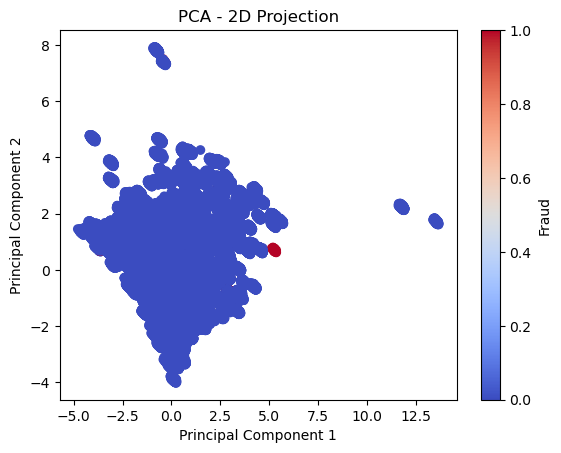

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming 'X_scaled' contains the scaled features
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

# Visualize the 2D projection of the data
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['is_fraud'], cmap='coolwarm')
plt.title("PCA - 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Fraud')
plt.show()

# Autoencoder

Epoch 1/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 0.9962 - val_loss: 0.9816
Epoch 2/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 0.9868 - val_loss: 0.9794
Epoch 3/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 0.9845 - val_loss: 0.9779
Epoch 4/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.9798 - val_loss: 0.9748
Epoch 5/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.9827 - val_loss: 0.9731
Epoch 6/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.9775 - val_loss: 0.9694
Epoch 7/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 0.9736 - val_loss: 0.9673
Epoch 8/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.9749 - val_loss: 0.9643
Epoch 9/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 0.9704 - val_loss: 0.9632
Epoch 10/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 0.9725 - val_loss: 0.9613
Epoch 11/50
13893/13893 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.9689 - val_loss: 0.95

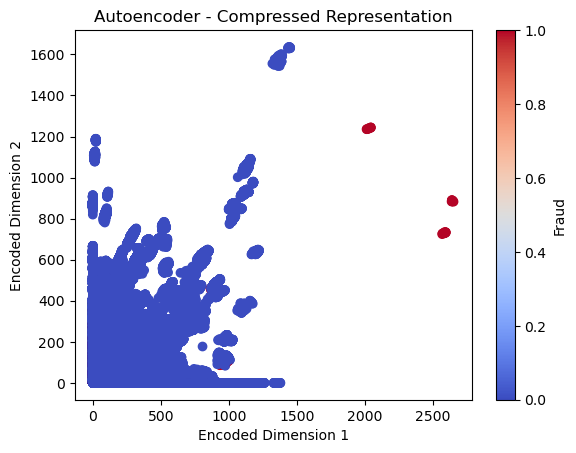

In [18]:
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Defining the Autoencoder model
autoencoder = Sequential([
    Dense(64, input_dim=X_scaled.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),  # Bottleneck layer
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(X_scaled.shape[1], activation='sigmoid')  # Output layer
])

autoencoder.compile(optimizer='adam', loss='mse')

# Train the Autoencoder
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=32, validation_split=0.2)

# Use the encoder to get the compressed representation of the data
encoder = Sequential(autoencoder.layers[:3])  # Extract the encoder part
X_encoded = encoder.predict(X_scaled)

# Visualize the compressed data
plt.scatter(X_encoded[:, 0], X_encoded[:, 1], c=df['is_fraud'], cmap='coolwarm')
plt.title("Autoencoder - Compressed Representation")
plt.xlabel("Encoded Dimension 1")
plt.ylabel("Encoded Dimension 2")
plt.colorbar(label='Fraud')
plt.show()

# Model Comparison

In [19]:
# Dictionary to store model performances
model_results = {}

# Function to evaluate and store model metrics
def evaluate_and_store(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    model_results[name] = {
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4),
        'AUC-ROC': round(auc, 4)
    }

# Evaluate all models
evaluate_and_store("Decision Tree", dt_model, X_test, y_test)
evaluate_and_store("Random Forest", rf_model, X_test, y_test)
evaluate_and_store("Logistic Regression", lr_model, X_test, y_test)
evaluate_and_store("MLP Neural Network", mlp_model, X_test, y_test)

# Create DataFrame for comparison
results_df = pd.DataFrame(model_results).T.sort_values(by="F1 Score", ascending=False)
results_df.style.background_gradient(cmap="YlGnBu").set_caption("📊 Model Performance Comparison")

,Accuracy,Precision,Recall,F1 Score,AUC-ROC
MLP Neural Network,0.998300,0.811000,0.720300,0.763000,0.995500
Random Forest,0.998200,0.934900,0.568800,0.707200,0.990500
Decision Tree,0.997400,0.659700,0.659700,0.659700,0.829200
Logistic Regression,0.995900,0.333300,0.053600,0.092400,0.929100
